### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [19]:
data = pd.read_csv('data/coupons.csv')

In [20]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [22]:
data.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684.000000,12684.000000,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
mean,63.301798,0.414144,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,19.154486,0.492593,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


In [23]:
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

* For 'car' column, 12,567 out of 12,684 are null (99.1%). The remaining 108 non-null values are statistically insignificant, so I am droppoing the column.

In [25]:
clean_data = data
clean_data = clean_data.drop(columns=['car'])

* For the other columns with NULL values (Bar, CoffeeHouse, CarryAway, RestaurantLessThan20, and Restaurant20To50):
  * The missing percentage is very small:
    * Bar: 0.84%
    * CoffeeHouse: 1.71%
    * CarryAway: 1.19%
    * RestaurantLessThan20: 1.02%
    * Restaurant20To50: 1.49%
  * Instead of dropping the records, I will fill them with the most common category in each column

In [26]:
cols_to_fill = ['Bar', 'CoffeeHouse', 'CarryAway', 
                'RestaurantLessThan20', 'Restaurant20To50']

for col in cols_to_fill:
    print(f"{col} mode: {clean_data[col].mode()[0]}")
    clean_data[col] = clean_data[col].fillna(clean_data[col].mode()[0])

Bar mode: never
CoffeeHouse mode: less1
CarryAway mode: 1~3
RestaurantLessThan20 mode: 1~3
Restaurant20To50 mode: less1


In [27]:
clean_data.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

4. What proportion of the total observations chose to accept the coupon?



In [39]:
total = clean_data['Y'].count()
accepted = clean_data.query("Y==1")['Y'].count()
proportion = accepted / total
print(f"Total observations: {total}")
print(f"Accepted coupons: {accepted}")
print(f"Proportion who accepted: {proportion:.2%}")

Total observations: 12684
Accepted coupons: 7210
Proportion who accepted: 56.84%


5. Use a bar plot to visualize the `coupon` column.

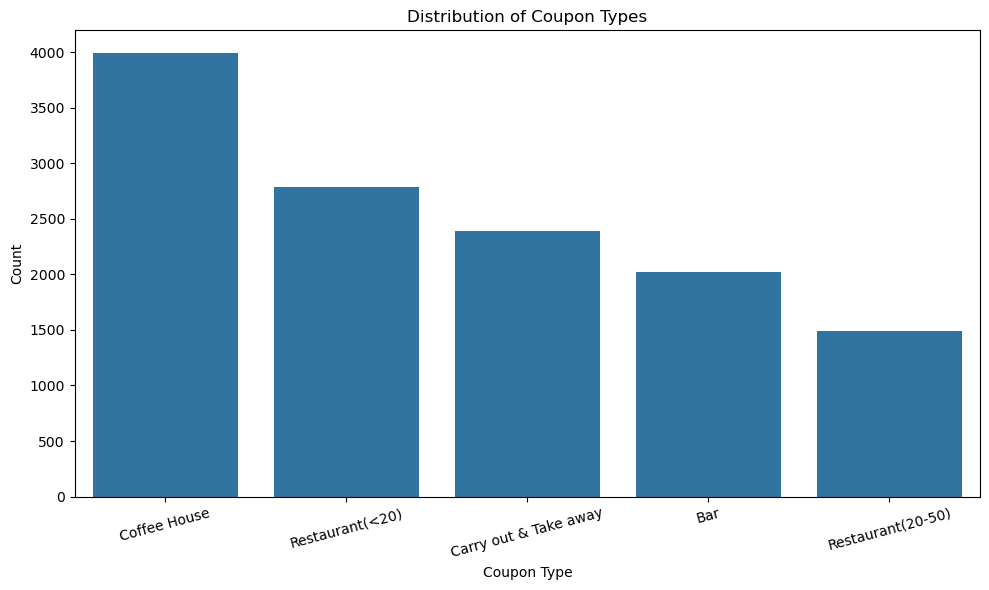

In [42]:
plt.figure(figsize=(10, 6))
sns.countplot(data=clean_data, x='coupon', order=clean_data['coupon'].value_counts().index)

plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

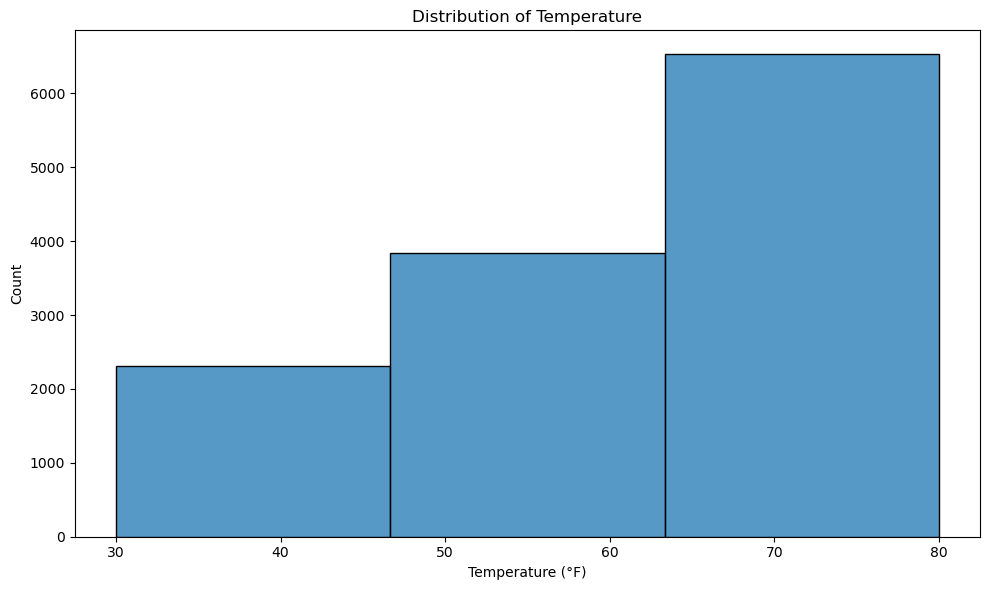

In [45]:
plt.figure(figsize=(10, 6))
sns.histplot(data=clean_data, x='temperature', bins=3)

plt.title('Distribution of Temperature')
plt.xlabel('Temperature (°F)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [47]:

bar_coupons = clean_data[clean_data['coupon'] == 'Bar']

print(f"Total rows in original clean_data: {len(clean_data)}")
print(f"Total rows in bar_coupons: {len(bar_coupons)}")

Total rows in original clean_data: 12684
Total rows in bar_coupons: 2017


2. What proportion of bar coupons were accepted?


In [48]:
total = bar_coupons['Y'].count()
accepted = bar_coupons.query("Y==1")['Y'].count()
proportion = accepted / total
print(f"Total observations (bar_coupons): {total}")
print(f"Accepted coupons (bar_coupons): {accepted}")
print(f"Proportion who accepted (bar_coupons): {proportion:.2%}")

Total observations (bar_coupons): 2017
Accepted coupons (bar_coupons): 827
Proportion who accepted (bar_coupons): 41.00%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [49]:
bar_coupons['Bar'].unique()

array(['never', 'less1', '1~3', 'gt8', '4~8'], dtype=object)

In [55]:

bar_three_or_less = bar_coupons.query("Bar in ['never', 'less1', '1~3']")
bar_more_than_three = bar_coupons.query("Bar in ['4~8', 'gt8']")

# bar_three_or_less acceptance rates
total_three_or_less = bar_three_or_less['Y'].count()
accepted_three_or_less = bar_three_or_less.query("Y==1")['Y'].count()
proportion_three_or_less = accepted_three_or_less / total_three_or_less

# bar_more_than_three acceptance rates
total_more_than_three = bar_more_than_three['Y'].count()
accepted_more_than_three = bar_more_than_three.query("Y==1")['Y'].count()
proportion_more_than_three = accepted_more_than_three / total_more_than_three


print(f"Acceptance rate for those who go to a bar 3 or fewer times: {proportion_three_or_less:.2%}")
print(f"Acceptance rate for those who go to a bar more than 3 times: {proportion_more_than_three:.2%}")

Acceptance rate for those who go to a bar 3 or fewer times: 37.07%
Acceptance rate for those who go to a bar more than 3 times: 76.88%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [56]:
bar_coupons['age'].unique()

array(['21', '46', '26', '31', '41', '50plus', '36', 'below21'],
      dtype=object)

In [59]:

bar_over25 = bar_coupons.query("Bar in ['4~8', 'gt8', '1~3'] and age not in ['below21', '21']")
bar_others = bar_coupons.query("Bar not in ['4~8', 'gt8', '1~3'] or age in ['below21', '21']")

# bar_over25 acceptance rates
total_over25 = bar_over25['Y'].count()
accepted_over25 = bar_over25.query("Y==1")['Y'].count()
proportion_over25 = accepted_over25 / total_over25

# bar_others acceptance rates
total_others = bar_others['Y'].count()
accepted_others = bar_others.query("Y==1")['Y'].count()
proportion_others = accepted_more_than_three / total_more_than_three


print(f"Acceptance rate for bar goers over 25 (more than once a month):: {proportion_over25:.2%}")
print(f"Acceptance rate for all others: {proportion_others:.2%}")
print(f"\nDifference: {proportion_over25 - proportion_others:.2%}")

Acceptance rate for bar goers over 25 (more than once a month):: 69.52%
Acceptance rate for all others: 76.88%

Difference: -7.36%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [61]:
bar_coupons['passanger'].unique()

array(['Kid(s)', 'Alone', 'Friend(s)', 'Partner'], dtype=object)

In [62]:
bar_coupons['occupation'].unique()

array(['Unemployed', 'Architecture & Engineering', 'Student',
       'Education&Training&Library', 'Healthcare Support',
       'Healthcare Practitioners & Technical', 'Sales & Related',
       'Management', 'Arts Design Entertainment Sports & Media',
       'Computer & Mathematical', 'Life Physical Social Science',
       'Personal Care & Service', 'Community & Social Services',
       'Office & Administrative Support', 'Construction & Extraction',
       'Legal', 'Retired', 'Installation Maintenance & Repair',
       'Transportation & Material Moving', 'Business & Financial',
       'Protective Service', 'Food Preparation & Serving Related',
       'Production Occupations',
       'Building & Grounds Cleaning & Maintenance',
       'Farming Fishing & Forestry'], dtype=object)

In [73]:
# Go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.
target_group = bar_coupons.query(
    "Bar in ['1~3', '4~8', 'gt8'] and \
     passanger not in ['Alone', 'Kid(s)'] and \
     occupation not in ['Farming Fishing & Forestry']"
)

# Group 2: All others
others = bar_coupons.query(
    "Bar not in ['1~3', '4~8', 'gt8'] or \
     passanger in ['Alone', 'Kid(s)'] or \
     occupation in ['Farming Fishing & Forestry']"
)

# Calculate acceptance rates
target_rate = target_group['Y'].mean()
others_rate = others['Y'].mean()

print(f"Acceptance rate for target group - Bars > once, passengers but no kids, not farming, fishing, nor forestry: {target_rate:.2%}")
print(f"Acceptance rate for all others: {others_rate:.2%}")
print(f"\nDifference: {target_rate - others_rate:.2%}")

Acceptance rate for target group - Bars > once, passengers but no kids, not farming, fishing, nor forestry: 71.79%
Acceptance rate for all others: 37.71%

Difference: 34.09%


6. Compare the acceptance rates between those drivers who:

- **Group_1**: go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- **Group_2**: go to bars more than once a month and are under the age of 30 *OR*
- **Group_3**: go to cheap restaurants more than 4 times a month and income is less than 50K.



In [65]:
bar_coupons['maritalStatus'].unique()

array(['Unmarried partner', 'Single', 'Married partner', 'Divorced',
       'Widowed'], dtype=object)

In [66]:
bar_coupons['income'].unique()

array(['$37500 - $49999', '$62500 - $74999', '$12500 - $24999',
       '$75000 - $87499', '$50000 - $62499', '$25000 - $37499',
       '$100000 or More', '$87500 - $99999', 'Less than $12500'],
      dtype=object)

In [67]:
bar_coupons['RestaurantLessThan20'].unique()

array(['4~8', '1~3', 'less1', 'gt8', 'never'], dtype=object)

In [68]:
bar_coupons['age'].unique()

array(['21', '46', '26', '31', '41', '50plus', '36', 'below21'],
      dtype=object)

In [72]:
# Group 1: Go to bars more than once a month AND had passengers that were not a kid AND not widowed
group1 = bar_coupons.query(
    "Bar in ['1~3', '4~8', 'gt8'] and \
     passanger not in ['Alone', 'Kid(s)']  and \
     maritalStatus != 'Widowed'"
)

# Group 2: Go to bars more than once a month AND under 30
group2 = bar_coupons.query(
    "Bar in ['1~3', '4~8', 'gt8'] and \
     age in ['21', '26', 'below21']"
)

# Group 3: Go to cheap restaurants more than 4 times a month AND income less than 50K
group3 = bar_coupons.query(
    "RestaurantLessThan20 in ['4~8', 'gt8'] and \
     income in ['$37500 - $49999', '$12500 - $24999', '$25000 - $37499', 'Less than $12500']"
)

# Combine all three groups using concat and drop duplicates
combined = pd.concat([group1, group2, group3]).drop_duplicates()

# All others
others = bar_coupons[~bar_coupons.index.isin(combined.index)]

# Calculate acceptance rates
group1_rate = group1['Y'].mean()
group2_rate = group2['Y'].mean()
group3_rate = group3['Y'].mean()
combined_rate = combined['Y'].mean()
others_rate = others['Y'].mean()

print(f"Group 1 - Bars > once, passengers but no kids, not widowed: {group1_rate:.2%}")
print(f"Group 2 - Bars > once, under 30: {group2_rate:.2%}")
print(f"Group 3 - Cheap restaurants > 4x, income < 50K: {group3_rate:.2%}")
print(f"\nCombined group acceptance rate: {combined_rate:.2%}")
print(f"All others acceptance rate: {others_rate:.2%}")
print(f"\nDifference: {combined_rate - others_rate:.2%}")

Group 1 - Bars > once, passengers but no kids, not widowed: 71.79%
Group 2 - Bars > once, under 30: 72.17%
Group 3 - Cheap restaurants > 4x, income < 50K: 45.35%

Combined group acceptance rate: 56.93%
All others acceptance rate: 33.19%

Difference: 23.74%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

<div style="background-color: #f9f9f9; padding: 10px; border: 1px solid #ccc;">
    
* **Frequency of bar visits is the strongest predictor of acceptance.** Drivers who visit bars more than 3 times a month accepted at nearly double the rate (**76.88%**) compared to those who go 3 or fewer times (**37.07%**).
* **Social context matters more than age.** Drivers who go to bars more than once a month without kids as passengers accepted at **71.79%**, while adding the age filter (over 25) slightly reduced the rate to **69.52%**.
* **Occupation play a role.** Removing drivers in farming, fishing, and forestry occupations from the frequent bar-goer group maintained a high acceptance rate of **71.79%**
* **Budget-conscious drivers are less likely to accept bar coupons.** Group 3 (cheap restaurant goers with income under $50K) had the lowest acceptance rate at **45.35%**, suggesting that cost-conscious drivers may not see bar coupons as aligned with their spending habits even if they dine out frequently.
* **The combined group still outperforms all others.** The combined group acceptance rate of **56.93%** versus **33.19%** for all others confirms that these lifestyle and behavioral factors together are meaningful predictors of bar coupon acceptance

<font size="3"><b>Overall Hypothesis:</b> Drivers who already frequent bars, travel without children, and work in non-agricultural occupations are the most likely to accept bar coupons.</font>

</div>

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  